## 1. Carregamento e Visualização dos Dados
Nesta etapa, importamos o dataset de seguros médicos e analisamos suas primeiras linhas e estrutura.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Carregar os dados
df = pd.read_csv('data/medical_insurance.csv') 

print('@-- Primeiras linhas do dataset original --@')
display(df.head())

print('\n@-- Informações Gerais --@')
df.info()

@-- Primeiras linhas do dataset original --@


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



@-- Informações Gerais --@
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.2+ KB


## Tratamento e Normalização

In [29]:
# !! Tratamento de variáveis !!
df_processed = df.copy()

# Label Encoding
df_processed['sex'] = df_processed['sex'].map({'female': 0, 'male': 1})
df_processed['smoker'] = df_processed['smoker'].map({'no': 0, 'yes': 1})

# One Hot Encoding
df_processed = pd.get_dummies(df_processed, columns=['region'], dtype=int)

# !! Separação de Entrada e Alvo !!
Y = df_processed['charges']
X = df_processed.drop(columns='charges')  

# !! Normalização !!
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

print('Preparação concluída com sucesso..')
print(f'Formato final dos atributos X: {X_scaled.shape}')
print(f'Formato final do alvo (y): {Y.shape}')

# Salvar o dataset processado
df_processed.to_csv('data/processed.csv', index=False)
X_scaled.to_csv('data/scaled_processed.csv', index=False)

Preparação concluída com sucesso..
Formato final dos atributos X: (1337, 9)
Formato final do alvo (y): (1337,)


## Configuração e Elbow Method

In [30]:
print(f'Dados prontos para clusterização: {df_processed.shape}')

print('\nCalculando a inércia para diferentes valores K...')
inercias = []
silhuetas = []
k_range = range(2, 13)

# Filtrando colunas para o perfilamento (excluindo charges)
colunas_perfil = [col for col in df_processed.columns if not col.startswith('charges') and not col.startswith('region')]
perfil = X_scaled[colunas_perfil]

# Calcular para cada K, de 2 a 12
for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    kmeans.fit(perfil)

    inercias.append(kmeans.inertia_)
    score = silhouette_score(perfil, kmeans.labels_)
    silhuetas.append(score)

print('Cálculos concluídos!')

Dados prontos para clusterização: (1337, 10)

Calculando a inércia para diferentes valores K...
Cálculos concluídos!


## Análise

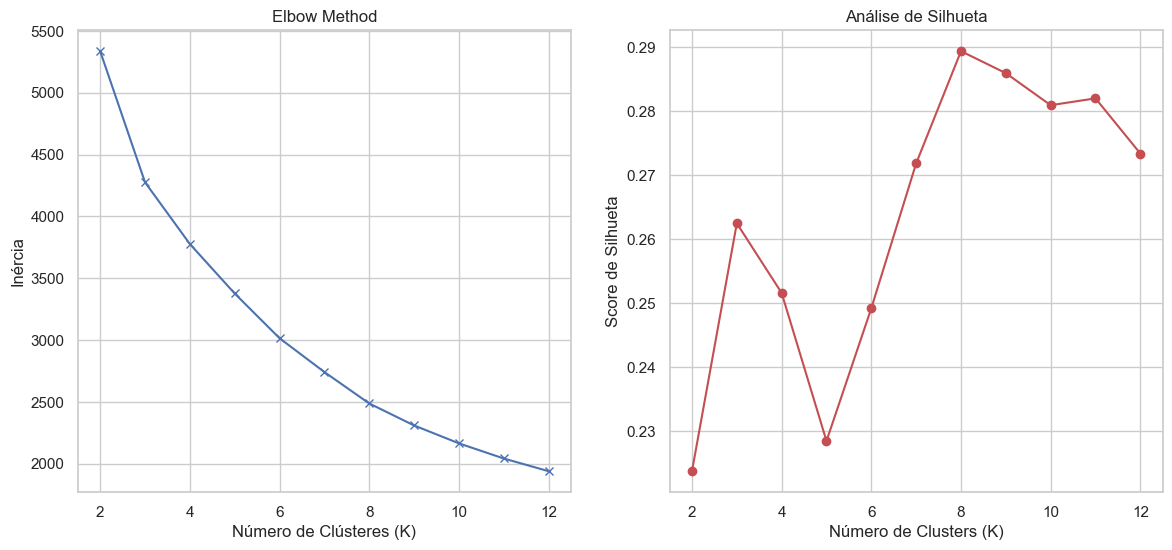


          TABELA DE ANÁLISE COMPLEMENTAR (K)           
K     | Inércia (WCSS)     | Silhouette Score
------------------------------------------------
K=2   | 5336.33            | 0.2238
K=3   | 4276.13            | 0.2625
K=4   | 3776.98            | 0.2516
K=5   | 3376.61            | 0.2285
K=6   | 3014.95            | 0.2492
K=7   | 2741.45            | 0.2718
K=8   | 2487.26            | 0.2893
K=9   | 2309.48            | 0.2859
K=10  | 2164.56            | 0.2809
K=11  | 2042.04            | 0.2820
K=12  | 1939.35            | 0.2734


In [31]:
# Gerando o gráfico
plt.figure(figsize=(14, 6))

# Elbow Method
plt.subplot(1, 2, 1)
plt.plot(k_range, inercias, 'bx-')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inércia')
plt.title('Elbow Method')
plt.grid(True)

# Silhouettes
plt.subplot(1, 2, 2)
plt.plot(k_range, silhuetas, 'ro-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Score de Silhueta')
plt.title('Análise de Silhueta')
plt.grid(True)

plt.show()

# Tabela de análise complementar
print("\n=======================================================")
print("          TABELA DE ANÁLISE COMPLEMENTAR (K)           ")
print("=======================================================")
print(f"{'K':<5} | {'Inércia (WCSS)':<18} | {'Silhouette Score':<16}")
print("-" * 48)

for k, inercia, silhueta in zip(k_range, inercias, silhuetas):
    print(f"K={k:<3} | {inercia:<18.2f} | {silhueta:.4f}")
print("=======================================================")

## K-Means Definitivo e Perfilamento

In [32]:
# !! Aplicação do K-Means definitivo !!
num_clusters = 3
print(f'\nTreinando o modelo com K={num_clusters}...')

kmeans_final = KMeans(n_clusters=num_clusters, n_init=20, random_state=42)
df_labels = kmeans_final.fit_predict(perfil)

df_original_clusters = df.copy()
df_original_clusters['cluster'] = df_labels

df_original_clusters.to_csv('processed_clusters.csv', index=False)

print('Agrupamento concluído e acoplado aos dados de treino.')


Treinando o modelo com K=3...
Agrupamento concluído e acoplado aos dados de treino.


In [33]:
print("\n=======================================================")
print("             PERFIL DOS CLUSTERS ENCONTRADOS           ")
print("=======================================================\n")

perfil_clusters = df_original_clusters.groupby('cluster').agg({
    'age': 'mean',
    'bmi': 'mean',
    'children': 'mean',
    'charges': ['mean', 'count']
}).reset_index()

perfil_clusters.columns = ['Cluster', 'Idade Média', 'IMC Médio', 'Filhos Média', 'Custo Médio (US$)', 'Total de Pessoas']
display(perfil_clusters) # display() deixa a tabela do perfil linda no Jupyter

# Cruzamentos de dados categorizados
print("\n--- Distribuição de Fumantes por Cluster ---")
display(pd.crosstab(df_original_clusters['cluster'], df_original_clusters['smoker']))

print("\n--- Distribuição de Regiões por Cluster ---")
display(pd.crosstab(df_original_clusters['cluster'], df_original_clusters['region']))


             PERFIL DOS CLUSTERS ENCONTRADOS           



,Cluster,Idade Média,IMC Médio,Filhos Média,Custo Médio (US$),Total de Pessoas
0,0,38.514599,30.708449,1.113139,32050.231832,274
1,1,39.100775,30.770930,1.094961,8099.700161,516
2,2,39.691042,30.539525,1.087751,8762.297300,547



--- Distribuição de Fumantes por Cluster ---


smoker,no,yes
cluster,,
0,0,274
1,516,0
2,547,0



--- Distribuição de Regiões por Cluster ---


region,northeast,northwest,southeast,southwest
cluster,,,,
0,67,58,91,58
1,125,131,134,126
2,132,135,139,141


## Visualização

[Exibindo Gráfico 2] Matriz de Correlação Geral.


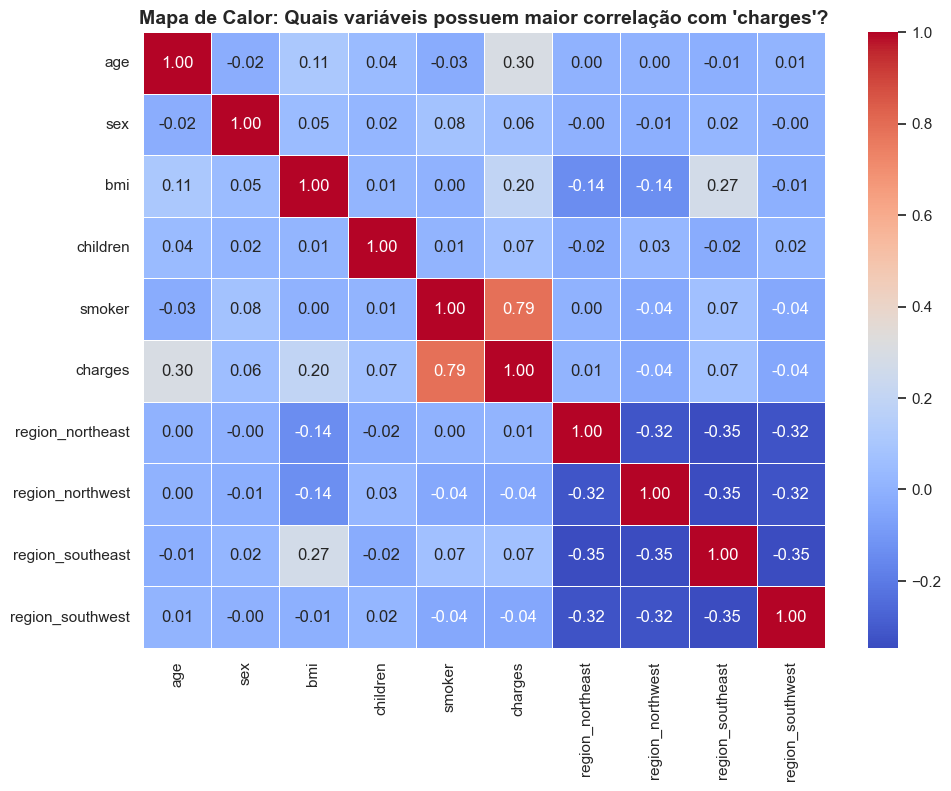

[Exibindo Gráfico 3] Dispersão de Idade, IMC e Fumo contra o Custo.


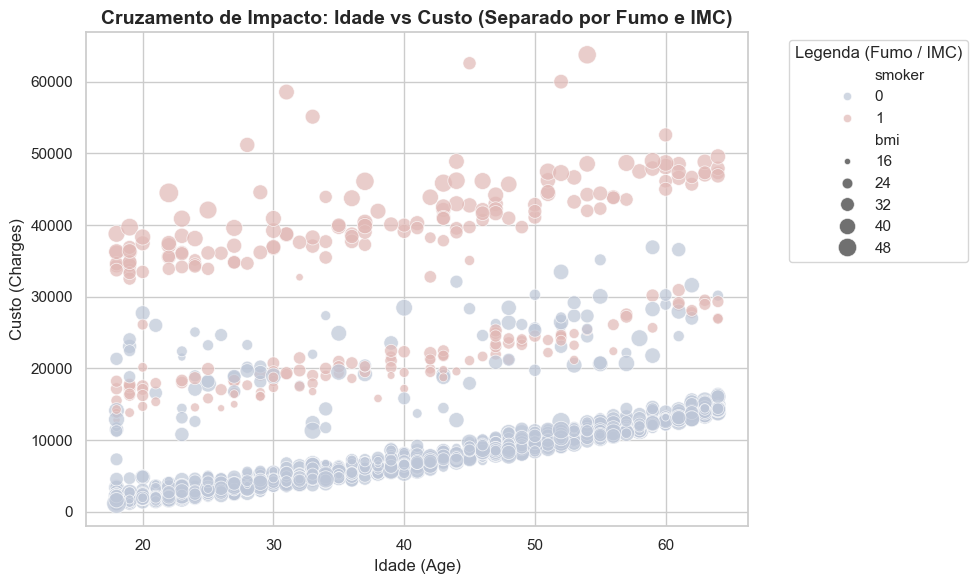


Todas as visualizações foram exibidas com sucesso!


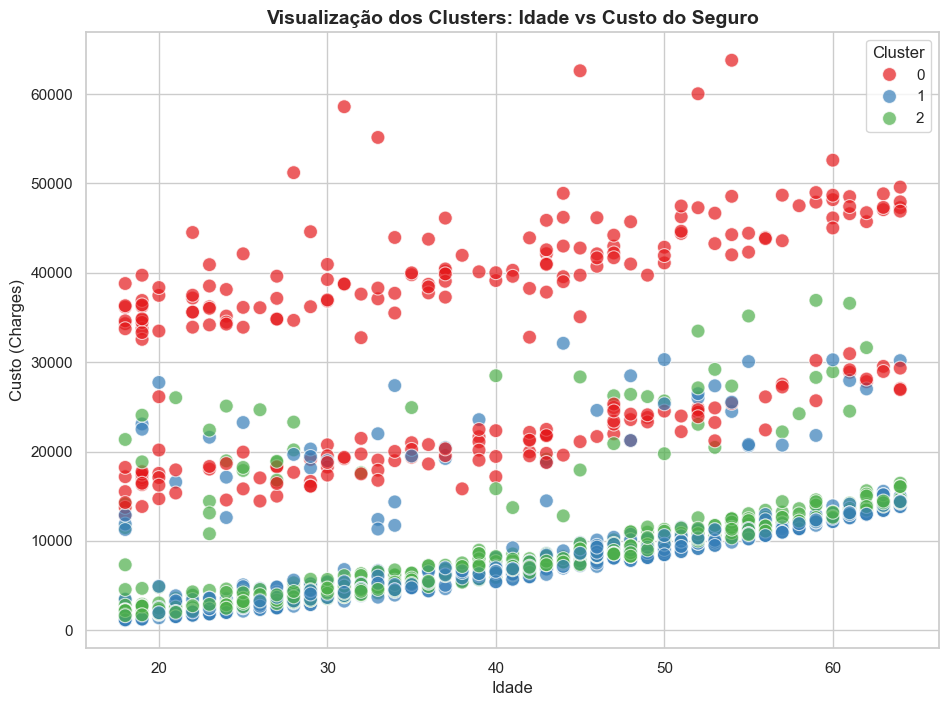

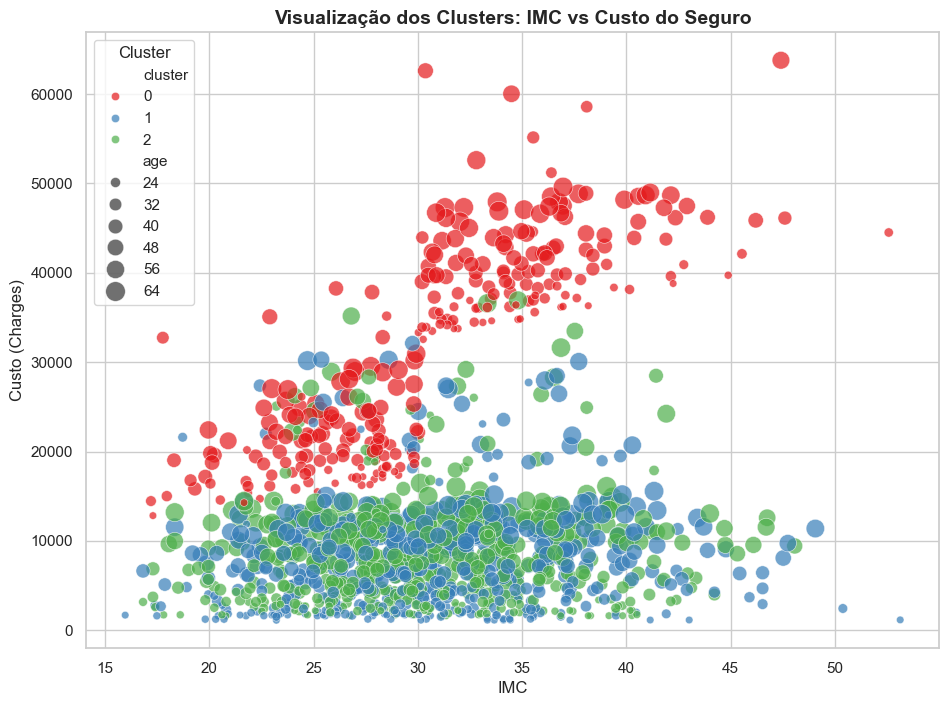

In [38]:
df_original = df_processed.copy()

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)



plt.figure(figsize=(11, 8))
# Calcula a matriz de correlação de Pearson
matriz_correlacao = df_original.corr()

# Destaca a linha/coluna do 'charges' para ver quem tem maior valor perto de 1 ou -1
sns.heatmap(matriz_correlacao, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa de Calor: Quais variáveis possuem maior correlação com 'charges'?", fontsize=14, fontweight="bold")
print("[Exibindo Gráfico 2] Matriz de Correlação Geral.")
plt.show()

plt.figure()
# Gráfico de dispersão cruzando Idade vs Custo, colorindo por fumo e tamanho pelo IMC
sns.scatterplot(
    x="age", 
    y="charges", 
    hue="smoker", 
    size="bmi", 
    sizes=(20, 200), 
    data=df_original, 
    palette="vlag", 
    alpha=0.7
)
plt.title("Cruzamento de Impacto: Idade vs Custo (Separado por Fumo e IMC)", fontsize=14, fontweight="bold")
plt.xlabel("Idade (Age)", fontsize=12)
plt.ylabel("Custo (Charges)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Legenda (Fumo / IMC)")
plt.tight_layout()
print("[Exibindo Gráfico 3] Dispersão de Idade, IMC e Fumo contra o Custo.")
plt.show()

print("\nTodas as visualizações foram exibidas com sucesso!")

# Visualização dos clusters encontrados
plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=df_original_clusters,
    x="age",
    y="charges",
    hue="cluster",
    palette="Set1",
    s=100,
    alpha=0.7
)

plt.title(
    "Visualização dos Clusters: Idade vs Custo do Seguro",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Idade")
plt.ylabel("Custo (Charges)")
plt.legend(title="Cluster")

plt.grid(True)
plt.show()

plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=df_original_clusters,
    x="bmi",
    y="charges",
    hue="cluster",
    palette="Set1",
    size="age",
    sizes=(30, 200),
    alpha=0.7
)

plt.title(
    "Visualização dos Clusters: IMC vs Custo do Seguro",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("IMC")
plt.ylabel("Custo (Charges)")
plt.legend(title="Cluster")

plt.grid(True)
plt.show()

## Regressão Global e por Cluster

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Função auxiliar para calcular todas as métricas de uma vez
def avaliar_modelo(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

# 1. CARREGAR DADOS (A partir da variável da célula anterior)
df = pd.read_csv('data/processed_clusters.csv') 

# A coluna 'cluster' vira variáveis dummy para a Regressão Global
df = pd.get_dummies(df, columns=['cluster'], dtype=int, drop_first=True)

X = df.drop(columns=['charges'])
y = df['charges']

# Dicionário com os modelos que vamos testar
modelos = {
    'Regressão Linear': LinearRegression(),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=5),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42)
}

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- RESULTADOS REGRESSÃO GLOBAL ---")
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    preds = modelo.predict(X_test)
    metricas = avaliar_modelo(y_test, preds)
    print(f"\n> {nome}:")
    print(f"  R²: {metricas['R2']:.4f} | RMSE: {metricas['RMSE']:.2f} | MAE: {metricas['MAE']:.2f}")


print("\n--- RESULTADOS REGRESSÃO POR CLUSTER ---")

# Vamos ler o arquivo novamente para garantir que a coluna 'cluster' esteja íntegra (sem get_dummies global)
df_clusters = pd.read_csv('data/processed_clusters.csv')

# Pegar a lista de clusters únicos de forma ordenada [0, 1, 2, 3]
clusters_unicos = sorted(df_clusters['cluster'].unique())

for c in clusters_unicos:
    print(f"\n================ CLUSTER {c} ================")
    
    # 1. Filtrar o dataset para conter apenas os dados do cluster atual
    df_c = df_clusters[df_clusters['cluster'] == c]
    
    # 2. Separar Entrada (X) e Alvo (y)
    # Como estamos DENTRO do cluster específico, removemos a coluna 'cluster' pois ela virou uma constante
    X_c = df_c.drop(columns=['charges', 'cluster'])
    y_c = df_c['charges']
    
    # 3. Divisão de Treino e Teste (80% / 20%) para este cluster específico
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)
    
    # 4. Treinar e avaliar cada um dos 3 algoritmos permitidos
    for nome, modelo in modelos.items():
        # Treina o modelo específico do algoritmo para o cluster C
        modelo.fit(X_train_c, y_train_c)
        
        # Faz as previsões nos dados de teste do cluster C
        preds_c = modelo.predict(X_test_c)
        
        # Calcula as métricas locais
        metricas_c = avaliar_modelo(y_test_c, preds_c)
        
        # Exibe os resultados formatados
        print(f"> {nome:16} -> R²: {metricas_c['R2']:.4f} | RMSE: {metricas_c['RMSE']:.2f} | MAE: {metricas_c['MAE']:.2f}")



--- RESULTADOS REGRESSÃO GLOBAL ---

> Regressão Linear:
  R²: 0.8019 | RMSE: 6033.25 | MAE: 4246.81

> KNN Regressor:
  R²: 0.0843 | RMSE: 12972.06 | MAE: 8651.49

> Decision Tree:
  R²: 0.8938 | RMSE: 4416.77 | MAE: 2598.24

--- RESULTADOS REGRESSÃO POR CLUSTER ---

================ CLUSTER 0 ================
> Regressão Linear -> R²: 0.7020 | RMSE: 5825.13 | MAE: 4157.25
> KNN Regressor    -> R²: 0.2594 | RMSE: 9182.86 | MAE: 6657.73
> Decision Tree    -> R²: 0.7836 | RMSE: 4964.14 | MAE: 2553.81

================ CLUSTER 1 ================
> Regressão Linear -> R²: 0.6894 | RMSE: 6619.69 | MAE: 4498.54
> KNN Regressor    -> R²: -0.1189 | RMSE: 12564.13 | MAE: 8863.45
> Decision Tree    -> R²: 0.7716 | RMSE: 5676.09 | MAE: 3276.26

================ CLUSTER 2 ================
> Regressão Linear -> R²: 0.7401 | RMSE: 6733.49 | MAE: 4745.81
> KNN Regressor    -> R²: -0.0072 | RMSE: 13254.17 | MAE: 9318.08
> Decision Tree    -> R²: 0.8203 | RMSE: 5598.82 | MAE: 2958.99


In [36]:
import joblib
import pandas as pd
from sklearn.tree import DecisionTreeRegressor


# carregar dados
df = pd.read_csv('data/processed_clusters.csv')


# separar cluster para não usar como entrada do modelo
X = df.drop(columns=['charges', 'cluster'])
y = df['charges']


# treinar modelo final
modelo_final = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

modelo_final.fit(X, y)


# salvar tudo necessário
artefatos_ml = {
    'modelo': modelo_final,
    'kmeans': kmeans_final,
    'scaler': scaler,
    'colunas': X.columns.tolist(),
    'colunas_cluster': colunas_perfil
}


joblib.dump(
    artefatos_ml,
    'modelo_charges.pkl'
)


print("Modelo salvo!")
print("Colunas regressão:", X.columns.tolist())
print("Colunas cluster:", colunas_perfil)

Modelo salvo!
Colunas regressão: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']
Colunas cluster: ['age', 'sex', 'bmi', 'children', 'smoker']
